# 04 — Probability calibration and inference contract

Turn the Task 3A **XGB Transformed** portfolio choice into a deployable probability model (`xgb-transformed-v1`): Platt-calibrate scores, freeze a validation operating threshold, evaluate test once, and document the public inference contract.

## What this notebook does

1. **Why calibrate** — Class-weighted XGBoost scores are useful for ranking, not as true fraud probabilities.
2. **Model** — XGB Transformed features only (`type`, `amount`, `oldbalanceOrg`, `log_amount`, `log_origin_balance`, `origin_balance_zero`). Explicit PaySim drain encodings are excluded.
3. **Temporal split** — Keep train / validation / test. Within train, carve chronological **model-fit** then **calibration** slices. Val/test never fit the booster or Platt map.
4. **Fit + Platt** — Train XGBoost on model-fit; fit sigmoid calibration on the calibration slice (raw margins → probabilities in `[0, 1]`).
5. **Quality** — Ranking stays essentially unchanged (monotone map); Brier / log-loss improve. Reliability diagrams check probability quality.
6. **Threshold** — On calibrated validation scores only: highest precision with recall ≥ 80%. Freeze that cut (e.g. `0.044`).
7. **Test once** — Score with the frozen calibrated threshold; compare to uncalibrated baselines for context.
8. **Inference contract** — Public request/response fields for the future API (`docs/inference_contract.md`).

**Out of scope:** Model C from notebook 03, drain-shortcut features, and writing `artifacts/` binaries (use `python -m fraud_risk.train_final` for that).


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from fraud_risk.calibration import (
    DEPLOYMENT_MODEL_VERSION,
    calibrate_scores,
    fit_platt_calibrator,
    plot_reliability,
    predict_raw_margin,
    probability_metrics,
    reliability_table,
)
from fraud_risk.data import load_raw_data
from fraud_risk.dataset import (
    TARGET_COLUMN,
    build_modeling_dataset,
    chronological_model_fit_calibration_split,
    split_target_summary,
)
from fraud_risk.features import (
    BALANCE_DRAIN_FEATURE_NAMES,
    XGB_TRANSFORMED_FEATURES,
    prepare_model_frame,
)
from fraud_risk.modeling import (
    DEFAULT_RECALL_FLOOR,
    build_xgboost_pipeline,
    classification_metrics_at_threshold,
    compute_scale_pos_weight,
    predict_proba_positive,
    ranking_metrics,
    select_operating_threshold,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}" if abs(x) < 1 else f"{x:,.4f}")
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.figsize": (7, 4)})

raw = load_raw_data(REPO_ROOT / "data" / "raw")
split = build_modeling_dataset(raw)
print(f"Loaded PaySim: {len(raw):,} rows")
print(
    f"Primary splits — train {len(split.train):,} / "
    f"val {len(split.validation):,} / test {len(split.test):,}"
)
print(f"Deployment features: {XGB_TRANSFORMED_FEATURES}")
print(f"Drain features excluded: {BALANCE_DRAIN_FEATURE_NAMES}")
print(f"Model version: {DEPLOYMENT_MODEL_VERSION}")
assert set(BALANCE_DRAIN_FEATURE_NAMES).isdisjoint(XGB_TRANSFORMED_FEATURES)


Loaded PaySim: 6,362,620 rows
Primary splits — train 1,938,484 / val 415,628 / test 416,297
Deployment features: ('type', 'amount', 'oldbalanceOrg', 'log_amount', 'log_origin_balance', 'origin_balance_zero')
Drain features excluded: ('amount_to_balance_ratio', 'amount_exceeds_balance')
Model version: xgb-transformed-v1


## 1. Why Calibration Matters

**Ranking** answers: *which transactions look more fraudulent than others?*  
**Calibration** answers: *when the model says 3%, how often is that actually fraud?*

Class imbalance weighting (`scale_pos_weight`) improves learning under rare fraud, but it also stretches raw booster scores. Those scores remain useful for ordering and threshold search; they should **not** be treated as true probabilities until calibrated.

This notebook fits **Platt (sigmoid) scaling** on a chronological calibration slice of training data only, then selects the operating threshold on **validation** calibrated probabilities.


## 2. Selected Deployment Model

Portfolio deployment choice from Task 3A: **XGB Transformed** (`xgb-transformed-v1`).

Uses: `type`, `amount`, `oldbalanceOrg`, `log_amount`, `log_origin_balance`, `origin_balance_zero`.

Excludes PaySim drain-artifact encodings: `amount_to_balance_ratio`, `amount_exceeds_balance`.

No hyperparameter tuning in this task.


In [2]:
print("XGB_TRANSFORMED_FEATURES:", list(XGB_TRANSFORMED_FEATURES))
print("Excludes drain features:", list(BALANCE_DRAIN_FEATURE_NAMES))


XGB_TRANSFORMED_FEATURES: ['type', 'amount', 'oldbalanceOrg', 'log_amount', 'log_origin_balance', 'origin_balance_zero']
Excludes drain features: ['amount_to_balance_ratio', 'amount_exceeds_balance']


## 3. Temporal Calibration Split

Primary train / validation / test boundaries are **unchanged**.

Within **train only**, carve:

- **model-fit** ≈ earliest 85% of training rows (by cumulative `step` counts)
- **calibration** ≈ latest 15% of training rows

No `step` is shared. Ordering:

`max(model_fit.step) < min(calibration.step) < min(validation.step) < min(test.step)`


In [3]:
cal_split = chronological_model_fit_calibration_split(split.train)
model_fit, calibration = cal_split.model_fit, cal_split.calibration
y_fit = model_fit[TARGET_COLUMN]
y_cal = calibration[TARGET_COLUMN]
y_val = split.validation[TARGET_COLUMN]
y_test = split.test[TARGET_COLUMN]

summary = split_target_summary(
    split.train,
    split.validation,
    split.test,
    model_fit=model_fit,
    calibration=calibration,
)
display(summary)

print(
    f"Step ranges — model_fit [{model_fit['step'].min()}, {model_fit['step'].max()}], "
    f"calibration [{calibration['step'].min()}, {calibration['step'].max()}], "
    f"validation [{split.validation['step'].min()}, {split.validation['step'].max()}], "
    f"test [{split.test['step'].min()}, {split.test['step'].max()}]"
)
assert model_fit["step"].max() < calibration["step"].min()
assert calibration["step"].max() < split.validation["step"].min()
assert split.validation["step"].max() < split.test["step"].min()
assert set(model_fit["step"]).isdisjoint(set(calibration["step"]))

print(f"model_fit rows: {len(model_fit):,} | calibration rows: {len(calibration):,}")
print(f"calibration fraud prevalence: {y_cal.mean():.6%}")


,split,rows,pct_rows,fraud_cases,fraud_rate,min_step,max_step
0,train,1938484,0.699710,3633,0.001874,1,322
1,validation,415628,0.150024,560,0.001347,323,376
2,test,416297,0.150266,4020,0.009657,377,743
3,model_fit,1649321,0.850830,3171,0.001923,1,279
4,calibration,289163,0.149170,462,0.001598,280,322


Step ranges — model_fit [1, 279], calibration [280, 322], validation [323, 376], test [377, 743]
model_fit rows: 1,649,321 | calibration rows: 289,163
calibration fraud prevalence: 0.159771%


## 4. Model Fit

Train **XGB Transformed** on the **model-fit** subset only.

`scale_pos_weight` is computed from **model-fit labels only** (never calibration, validation, or test).


In [4]:
X_fit = prepare_model_frame(model_fit, XGB_TRANSFORMED_FEATURES)
X_cal = prepare_model_frame(calibration, XGB_TRANSFORMED_FEATURES)
X_val = prepare_model_frame(split.validation, XGB_TRANSFORMED_FEATURES)
X_test = prepare_model_frame(split.test, XGB_TRANSFORMED_FEATURES)

scale_pos_weight = compute_scale_pos_weight(y_fit)
print(f"model-fit positives: {int((y_fit == 1).sum()):,}")
print(f"model-fit negatives: {int((y_fit == 0).sum()):,}")
print(f"scale_pos_weight (model-fit only): {scale_pos_weight:.4f}")

model = build_xgboost_pipeline(
    scale_pos_weight=scale_pos_weight,
    feature_names=XGB_TRANSFORMED_FEATURES,
)
model.fit(X_fit, y_fit)
print("Fitted XGB Transformed on model-fit subset.")


model-fit positives: 3,171
model-fit negatives: 1,646,150
scale_pos_weight (model-fit only): 519.1265
Fitted XGB Transformed on model-fit subset.


## 5. Platt Calibration

1. Score the calibration subset with the XGBoost **raw margin** (pre-sigmoid).
2. Fit Logistic Regression: `margin → isFraud` (unweighted).
3. Map future margins through that sigmoid to calibrated probabilities.

Calibrator is fit on the **calibration subset only**.


Platt coef=1.371906, intercept=-6.245551
Calibrated probability range on calibration: [0.000000, 0.999423]


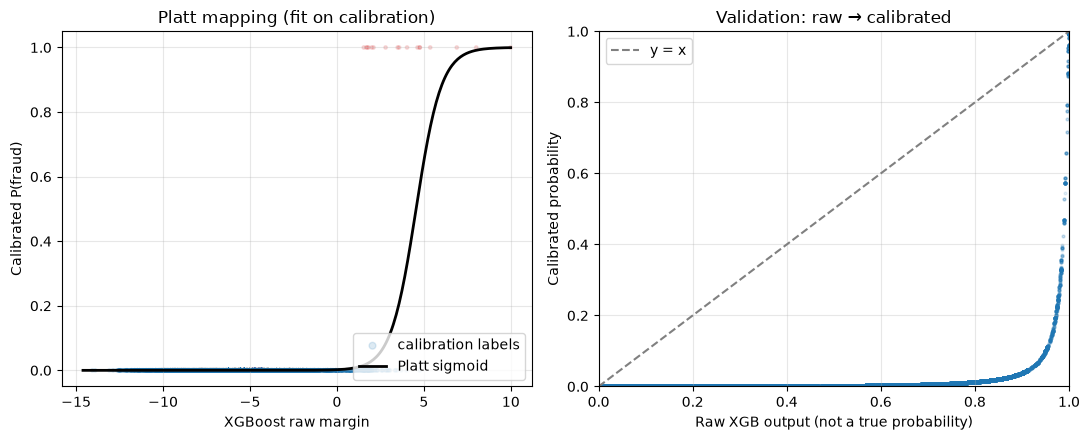

In [5]:
cal_margin = predict_raw_margin(model, X_cal)
val_margin = predict_raw_margin(model, X_val)
test_margin = predict_raw_margin(model, X_test)

# Raw probability-like booster output (NOT a calibrated probability).
cal_raw = predict_proba_positive(model, X_cal)
val_raw = predict_proba_positive(model, X_val)
test_raw = predict_proba_positive(model, X_test)

calibrator = fit_platt_calibrator(cal_margin, y_cal)
print(f"Platt coef={calibrator.coef_:.6f}, intercept={calibrator.intercept_:.6f}")

cal_calibrated = calibrate_scores(calibrator, cal_margin)
val_calibrated = calibrate_scores(calibrator, val_margin)
test_calibrated = calibrate_scores(calibrator, test_margin)

assert np.isfinite(cal_calibrated).all()
assert ((cal_calibrated >= 0.0) & (cal_calibrated <= 1.0)).all()
print(
    f"Calibrated probability range on calibration: "
    f"[{cal_calibrated.min():.6f}, {cal_calibrated.max():.6f}]"
)

# Platt sigmoid learned on the calibration subset.
margin_grid = np.linspace(float(cal_margin.min()), float(cal_margin.max()), 300)
platt_curve = calibrate_scores(calibrator, margin_grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
rng = np.random.default_rng(42)
idx = rng.choice(len(cal_margin), size=min(8000, len(cal_margin)), replace=False)
y_cal_arr = y_cal.to_numpy()
ax.scatter(
    cal_margin[idx],
    y_cal_arr[idx],
    s=6,
    alpha=0.15,
    c=np.where(y_cal_arr[idx] == 1, "C3", "C0"),
    label="calibration labels",
)
ax.plot(margin_grid, platt_curve, color="black", lw=2, label="Platt sigmoid")
ax.set_xlabel("XGBoost raw margin")
ax.set_ylabel("Calibrated P(fraud)")
ax.set_title("Platt mapping (fit on calibration)")
ax.legend(loc="lower right", markerscale=2)

ax = axes[1]
ax.scatter(val_raw, val_calibrated, s=4, alpha=0.12, color="C0")
ax.plot([0, 1], [0, 1], ls="--", color="gray", label="y = x")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Raw XGB output (not a true probability)")
ax.set_ylabel("Calibrated probability")
ax.set_title("Validation: raw → calibrated")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


## 6. Calibration Quality

Compare ranking (PR-AUC / ROC-AUC) and probability metrics (Brier, log loss) for raw vs calibrated scores. Calibration should not materially change ranking under a monotone Platt map with positive slope.

Plots below: score distributions (raw vs calibrated), Brier/log-loss bars, and reliability diagrams.


,split,raw_PR_AUC,cal_PR_AUC,raw_ROC_AUC,cal_ROC_AUC,raw_Brier,cal_Brier,raw_log_loss,cal_log_loss
0,calibration,0.676928,0.676928,0.998438,0.998438,0.021794,0.000836,0.073571,0.003251
1,validation,0.616242,0.616242,0.998303,0.998303,0.020609,0.000810,0.069980,0.003113


Ranking deltas (calibrated - raw) on validation:
  PR-AUC delta: 1.110223e-16
  ROC-AUC delta: 0.000000e+00
Validation Brier raw=0.020609 → cal=0.000810
Validation log loss raw=0.069980 → cal=0.003113


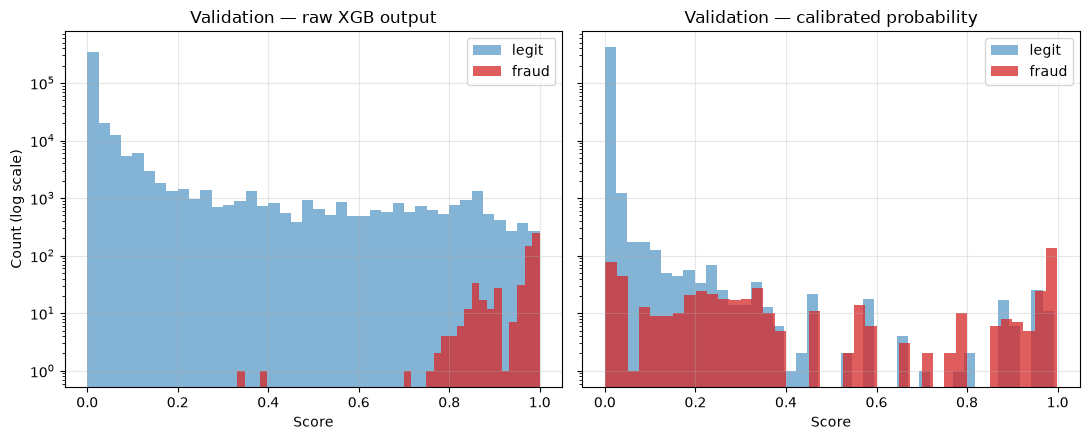

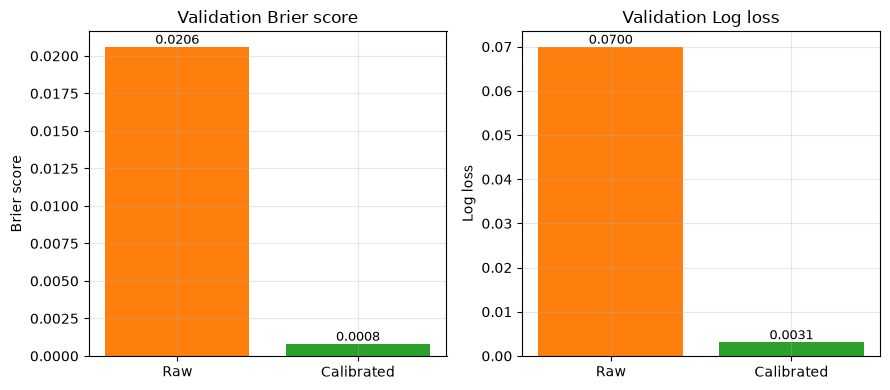

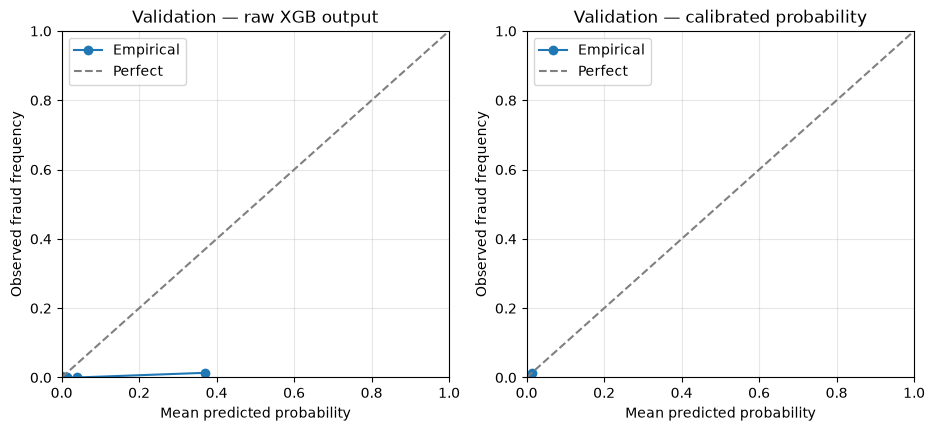

Validation reliability table (calibrated, quantile bins):


,bin,bin_label,count,mean_predicted,observed_fraud_rate,status
0,0,"[2.88375e-12, 5.72385e-09)",41549,0.000000,0.000000,ok
1,1,"[5.72385e-09, 4.3661e-08)",41560,0.000000,0.000000,ok
2,2,"[4.3661e-08, 2.5431e-07)",41502,0.000000,0.000000,ok
3,3,"[2.5431e-07, 9.42473e-07)",39669,0.000001,0.000000,ok
4,4,"[9.42473e-07, 1.79758e-06)",43525,0.000001,0.000000,ok
5,5,"[1.79758e-06, 2.90543e-06)",38433,0.000002,0.000000,ok
6,6,"[2.90543e-06, 4.7778e-06)",43549,0.000004,0.000000,ok
7,7,"[4.7778e-06, 7.94123e-06)",41113,0.000006,0.000000,ok
8,8,"[7.94123e-06, 5.9591e-05)",43144,0.000025,0.000000,ok
9,9,"[5.9591e-05, 0.999423)",41584,0.014632,0.013467,ok


In [6]:
def pack_metrics(name, y, raw, calibrated):
    rank_raw = ranking_metrics(y, raw)
    rank_cal = ranking_metrics(y, calibrated)
    prob_raw = probability_metrics(y, raw)
    prob_cal = probability_metrics(y, calibrated)
    return {
        "split": name,
        "raw_PR_AUC": rank_raw["average_precision"],
        "cal_PR_AUC": rank_cal["average_precision"],
        "raw_ROC_AUC": rank_raw["roc_auc"],
        "cal_ROC_AUC": rank_cal["roc_auc"],
        "raw_Brier": prob_raw["brier_score"],
        "cal_Brier": prob_cal["brier_score"],
        "raw_log_loss": prob_raw["log_loss"],
        "cal_log_loss": prob_cal["log_loss"],
    }

quality = pd.DataFrame(
    [
        pack_metrics("calibration", y_cal, cal_raw, cal_calibrated),
        pack_metrics("validation", y_val, val_raw, val_calibrated),
    ]
)
display(quality)

val_row = quality.loc[quality["split"] == "validation"].iloc[0]
print("Ranking deltas (calibrated - raw) on validation:")
print(f"  PR-AUC delta: {val_row['cal_PR_AUC'] - val_row['raw_PR_AUC']:.6e}")
print(f"  ROC-AUC delta: {val_row['cal_ROC_AUC'] - val_row['raw_ROC_AUC']:.6e}")
print(f"Validation Brier raw={val_row['raw_Brier']:.6f} → cal={val_row['cal_Brier']:.6f}")
print(f"Validation log loss raw={val_row['raw_log_loss']:.6f} → cal={val_row['cal_log_loss']:.6f}")

# Score distributions (log counts): class weighting pushes raw mass high; calibration compresses it.
y_val_arr = y_val.to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, scores, title in (
    (axes[0], val_raw, "Validation — raw XGB output"),
    (axes[1], val_calibrated, "Validation — calibrated probability"),
):
    ax.hist(scores[y_val_arr == 0], bins=40, alpha=0.55, label="legit", color="C0")
    ax.hist(scores[y_val_arr == 1], bins=40, alpha=0.75, label="fraud", color="C3")
    ax.set_yscale("log")
    ax.set_xlabel("Score")
    ax.set_title(title)
    ax.legend()
axes[0].set_ylabel("Count (log scale)")
plt.tight_layout()
plt.show()

# Probability-quality comparison (lower is better).
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
metrics_plot = [
    ("Brier score", val_row["raw_Brier"], val_row["cal_Brier"]),
    ("Log loss", val_row["raw_log_loss"], val_row["cal_log_loss"]),
]
for ax, (name, raw_v, cal_v) in zip(axes, metrics_plot):
    bars = ax.bar(["Raw", "Calibrated"], [raw_v, cal_v], color=["C1", "C2"])
    ax.set_title(f"Validation {name}")
    ax.set_ylabel(name)
    for bar, val in zip(bars, [raw_v, cal_v]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.4f}",
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_reliability(
    y_val, val_raw, n_bins=10, strategy="quantile",
    title="Validation — raw XGB output", ax=axes[0],
)
plot_reliability(
    y_val, val_calibrated, n_bins=10, strategy="quantile",
    title="Validation — calibrated probability", ax=axes[1],
)
plt.show()

print("Validation reliability table (calibrated, quantile bins):")
rel = reliability_table(y_val, val_calibrated, n_bins=10, strategy="quantile")
display(rel)


## 7. Validation Operating Threshold

Using **calibrated** validation probabilities only: maximize precision subject to `recall >= 0.80` when feasible (same policy as Tasks 2–3A). Freeze the selected threshold.

The precision–recall **curve** is the same for raw and calibrated scores: a strictly monotone Platt map does not change ranking (validation PR-AUC delta is ~0). The plot therefore draws one shared curve and marks the two operating points, which live on different score scales (raw threshold near 0.91 vs calibrated 0.044) but similar recall/precision.


Frozen calibrated threshold: 0.044000
Highest-precision threshold among those with recall >= 80% (provisional portfolio-project policy; validation data only).


,split,prevalence,threshold,precision,recall,f1,false_positives,false_negatives,alert_rate,PR_AUC,ROC_AUC,Brier,log_loss
0,validation,0.001347,0.044000,0.289575,0.803571,0.425733,1104,110,0.003739,0.616242,0.998303,0.000810,0.003113


Raw vs calibrated operating points (same ranking; thresholds are not comparable): raw thr=0.910 P=0.294 R=0.804; cal thr=0.044 P=0.290 R=0.804


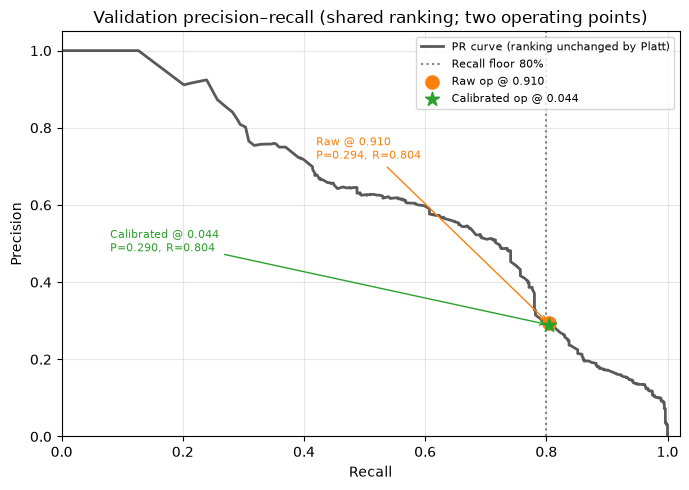

In [7]:
from sklearn.metrics import precision_recall_curve

threshold, reason, thresh_table = select_operating_threshold(
    y_val, val_calibrated, recall_floor=DEFAULT_RECALL_FLOOR
)
print(f"Frozen calibrated threshold: {threshold:.6f}")
print(reason)

val_metrics = classification_metrics_at_threshold(y_val, val_calibrated, threshold=threshold)
val_prob = probability_metrics(y_val, val_calibrated)
val_rank = ranking_metrics(y_val, val_calibrated)

val_report = {
    "split": "validation",
    "prevalence": float(y_val.mean()),
    "threshold": threshold,
    "precision": val_metrics["precision"],
    "recall": val_metrics["recall"],
    "f1": val_metrics["f1"],
    "false_positives": val_metrics["false_positives"],
    "false_negatives": val_metrics["false_negatives"],
    "alert_rate": val_metrics["alert_rate"],
    "PR_AUC": val_rank["average_precision"],
    "ROC_AUC": val_rank["roc_auc"],
    "Brier": val_prob["brier_score"],
    "log_loss": val_prob["log_loss"],
}
display(pd.DataFrame([val_report]))

# Raw operating point for visual comparison (not used for the frozen threshold).
raw_thr_preview, _, _ = select_operating_threshold(y_val, val_raw, recall_floor=DEFAULT_RECALL_FLOOR)
raw_at = classification_metrics_at_threshold(y_val, val_raw, threshold=raw_thr_preview)

# One PR curve: strictly monotone Platt preserves ranking, so raw and calibrated
# curves coincide. The comparison that matters is the two operating points.
prec, rec, _ = precision_recall_curve(y_val, val_calibrated)
print(
    "Raw vs calibrated operating points (same ranking; thresholds are not comparable): "
    f"raw thr={raw_thr_preview:.3f} P={raw_at['precision']:.3f} R={raw_at['recall']:.3f}; "
    f"cal thr={threshold:.3f} P={val_metrics['precision']:.3f} R={val_metrics['recall']:.3f}"
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, color="0.35", lw=2, label="PR curve (ranking unchanged by Platt)")
ax.axvline(DEFAULT_RECALL_FLOOR, color="gray", ls=":", label=f"Recall floor {DEFAULT_RECALL_FLOOR:.0%}")
ax.scatter(
    [raw_at["recall"]], [raw_at["precision"]],
    s=90, color="C1", zorder=3, marker="o",
    label=f"Raw op @ {raw_thr_preview:.3f}",
)
ax.scatter(
    [val_metrics["recall"]], [val_metrics["precision"]],
    s=110, color="C2", zorder=3, marker="*",
    label=f"Calibrated op @ {threshold:.3f}",
)
ax.annotate(
    f"Raw @ {raw_thr_preview:.3f}\nP={raw_at['precision']:.3f}, R={raw_at['recall']:.3f}",
    xy=(raw_at["recall"], raw_at["precision"]),
    xytext=(0.42, 0.72),
    arrowprops=dict(arrowstyle="->", color="C1"),
    color="C1",
    fontsize=8,
)
ax.annotate(
    f"Calibrated @ {threshold:.3f}\nP={val_metrics['precision']:.3f}, R={val_metrics['recall']:.3f}",
    xy=(val_metrics["recall"], val_metrics["precision"]),
    xytext=(0.08, 0.48),
    arrowprops=dict(arrowstyle="->", color="C2"),
    color="C2",
    fontsize=8,
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Validation precision–recall (shared ranking; two operating points)")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


## 8. Final Test Evaluation

Score test **once** with the frozen calibrated threshold. Also compare operational metrics to:

1. raw (uncalibrated) scores from this same model-fit model at a raw validation-selected threshold;
2. the Task 3A uncalibrated XGB Transformed reference (full-train fit, no Platt scaling).


,split,prevalence,threshold,precision,recall,f1,false_positives,false_negatives,alert_rate,PR_AUC,ROC_AUC,Brier,log_loss
0,validation,0.001347,0.044000,0.289575,0.803571,0.425733,1104,110,0.003739,0.616242,0.998303,0.000810,0.003113
1,test,0.009657,0.044000,0.705576,0.808955,0.753737,1357,768,0.011071,0.867370,0.997825,0.004131,0.014165


Uncalibrated (same model-fit model) threshold: 0.910000
Highest-precision threshold among those with recall >= 80% (provisional portfolio-project policy; validation data only).
Task 3A-style uncalibrated reference threshold: 0.901000
Highest-precision threshold among those with recall >= 80% (provisional portfolio-project policy; validation data only).


,config,split,threshold,precision,recall,f1,false_positives,false_negatives,alert_rate,PR_AUC,ROC_AUC
0,Task3A_XGB_Transformed_uncalibrated,test,0.901000,0.670128,0.818657,0.736984,1620,729,0.011797,0.861360,0.997679
1,model_fit_raw_uncalibrated,test,0.910000,0.708079,0.806716,0.754186,1337,777,0.011002,0.867370,0.997825
2,model_fit_platt_calibrated,test,0.044000,0.705576,0.808955,0.753737,1357,768,0.011071,0.867370,0.997825


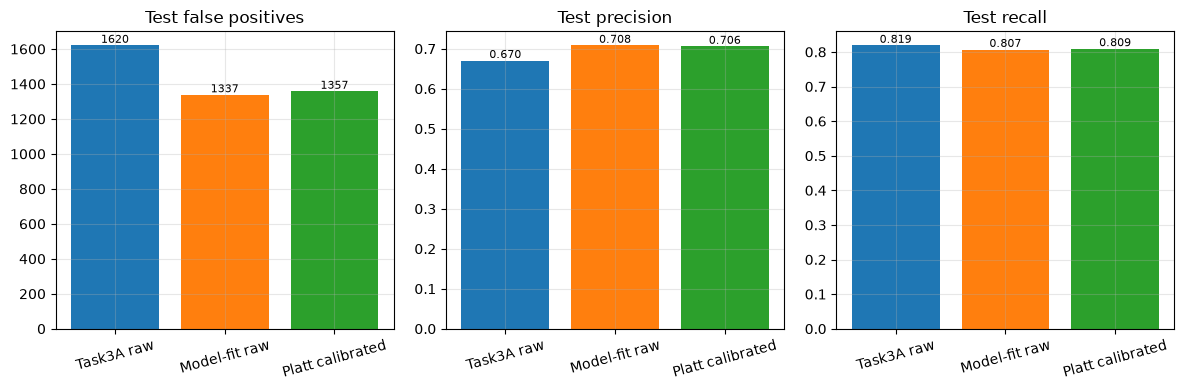

Ranking stability (validation raw vs calibrated): stable (monotone map; deltas ~0)
Validation ranking deltas — PR-AUC 1.110e-16, ROC-AUC 0.000e+00


In [8]:
test_metrics = classification_metrics_at_threshold(
    y_test, test_calibrated, threshold=threshold
)
test_prob = probability_metrics(y_test, test_calibrated)
test_rank = ranking_metrics(y_test, test_calibrated)

test_report = {
    "split": "test",
    "prevalence": float(y_test.mean()),
    "threshold": threshold,
    "precision": test_metrics["precision"],
    "recall": test_metrics["recall"],
    "f1": test_metrics["f1"],
    "false_positives": test_metrics["false_positives"],
    "false_negatives": test_metrics["false_negatives"],
    "alert_rate": test_metrics["alert_rate"],
    "PR_AUC": test_rank["average_precision"],
    "ROC_AUC": test_rank["roc_auc"],
    "Brier": test_prob["brier_score"],
    "log_loss": test_prob["log_loss"],
}
display(pd.DataFrame([val_report, test_report]))

# Same model-fit model, uncalibrated operating policy (for calibration contrast).
raw_thr, raw_reason, _ = select_operating_threshold(y_val, val_raw, recall_floor=DEFAULT_RECALL_FLOOR)
raw_val = classification_metrics_at_threshold(y_val, val_raw, threshold=raw_thr)
raw_test = classification_metrics_at_threshold(y_test, test_raw, threshold=raw_thr)
print(f"Uncalibrated (same model-fit model) threshold: {raw_thr:.6f}")
print(raw_reason)

# Task 3A-style reference: full train, no calibration holdout.
X_train_full = prepare_model_frame(split.train, XGB_TRANSFORMED_FEATURES)
y_train_full = split.train[TARGET_COLUMN]
ref_weight = compute_scale_pos_weight(y_train_full)
ref_model = build_xgboost_pipeline(
    scale_pos_weight=ref_weight,
    feature_names=XGB_TRANSFORMED_FEATURES,
)
ref_model.fit(X_train_full, y_train_full)
ref_val = predict_proba_positive(ref_model, X_val)
ref_test = predict_proba_positive(ref_model, X_test)
ref_thr, ref_reason, _ = select_operating_threshold(y_val, ref_val, recall_floor=DEFAULT_RECALL_FLOOR)
ref_val_m = classification_metrics_at_threshold(y_val, ref_val, threshold=ref_thr)
ref_test_m = classification_metrics_at_threshold(y_test, ref_test, threshold=ref_thr)
print(f"Task 3A-style uncalibrated reference threshold: {ref_thr:.6f}")
print(ref_reason)

compare = pd.DataFrame(
    [
        {
            "config": "Task3A_XGB_Transformed_uncalibrated",
            "split": "test",
            "threshold": ref_thr,
            "precision": ref_test_m["precision"],
            "recall": ref_test_m["recall"],
            "f1": ref_test_m["f1"],
            "false_positives": ref_test_m["false_positives"],
            "false_negatives": ref_test_m["false_negatives"],
            "alert_rate": ref_test_m["alert_rate"],
            "PR_AUC": ranking_metrics(y_test, ref_test)["average_precision"],
            "ROC_AUC": ranking_metrics(y_test, ref_test)["roc_auc"],
        },
        {
            "config": "model_fit_raw_uncalibrated",
            "split": "test",
            "threshold": raw_thr,
            "precision": raw_test["precision"],
            "recall": raw_test["recall"],
            "f1": raw_test["f1"],
            "false_positives": raw_test["false_positives"],
            "false_negatives": raw_test["false_negatives"],
            "alert_rate": raw_test["alert_rate"],
            "PR_AUC": ranking_metrics(y_test, test_raw)["average_precision"],
            "ROC_AUC": ranking_metrics(y_test, test_raw)["roc_auc"],
        },
        {
            "config": "model_fit_platt_calibrated",
            "split": "test",
            "threshold": threshold,
            "precision": test_metrics["precision"],
            "recall": test_metrics["recall"],
            "f1": test_metrics["f1"],
            "false_positives": test_metrics["false_positives"],
            "false_negatives": test_metrics["false_negatives"],
            "alert_rate": test_metrics["alert_rate"],
            "PR_AUC": test_rank["average_precision"],
            "ROC_AUC": test_rank["roc_auc"],
        },
    ]
)
display(compare)

short_labels = ["Task3A raw", "Model-fit raw", "Platt calibrated"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col, title in (
    (axes[0], "false_positives", "Test false positives"),
    (axes[1], "precision", "Test precision"),
    (axes[2], "recall", "Test recall"),
):
    vals = compare[col].to_numpy()
    bars = ax.bar(short_labels, vals, color=["C0", "C1", "C2"])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, vals):
        label = f"{val:.0f}" if col == "false_positives" else f"{val:.3f}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label,
                ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

rank_stable = (
    abs(val_row["cal_PR_AUC"] - val_row["raw_PR_AUC"]) < 1e-6
    and abs(val_row["cal_ROC_AUC"] - val_row["raw_ROC_AUC"]) < 1e-6
)
print(
    "Ranking stability (validation raw vs calibrated): "
    + ("stable (monotone map; deltas ~0)" if rank_stable else "small numerical deltas; inspect quality table")
)
print(
    f"Validation ranking deltas — PR-AUC {val_row['cal_PR_AUC']-val_row['raw_PR_AUC']:.3e}, "
    f"ROC-AUC {val_row['cal_ROC_AUC']-val_row['raw_ROC_AUC']:.3e}"
)


## 9. Inference Contract

Public API fields (to be implemented later):

**Request:** `transaction_type`, `amount`, `origin_balance` (no engineered features).

**Response:** `fraud_probability` (calibrated), `decision` (`review` / `pass`), `threshold`, `model_version` (`xgb-transformed-v1`).

See `docs/inference_contract.md` for validation rules and internal mapping (`transaction_type → type`, `origin_balance → oldbalanceOrg`).


In [9]:
print("Public request example:")
print(
    {
        "transaction_type": "TRANSFER",
        "amount": 8500.0,
        "origin_balance": 9000.0,
    }
)
print("Public response shape:")
print(
    {
        "fraud_probability": "<calibrated float in [0,1]>",
        "decision": "review|pass",
        "threshold": float(threshold),
        "model_version": DEPLOYMENT_MODEL_VERSION,
    }
)


Public request example:
{'transaction_type': 'TRANSFER', 'amount': 8500.0, 'origin_balance': 9000.0}
Public response shape:
{'fraud_probability': '<calibrated float in [0,1]>', 'decision': 'review|pass', 'threshold': 0.044, 'model_version': 'xgb-transformed-v1'}


## 10. Conclusions

- Ranking and calibration are different goals; class-weighted XGBoost scores need calibration before probability interpretation.
- Calibration is learned from **past** training data only (late train slice); validation chooses the threshold; test is scored once.
- The frozen threshold is a **business-policy** choice (high precision under a recall floor), not a claim about true authorization economics.
- `docs/inference_contract.md` defines the future FastAPI interface; the service is not implemented yet.


In [10]:
print("=" * 72)
print("TASK 4 SUMMARY")
print("=" * 72)
print(
    f"Temporal boundaries — model_fit steps [{model_fit['step'].min()}, {model_fit['step'].max()}], "
    f"calibration [{calibration['step'].min()}, {calibration['step'].max()}], "
    f"validation [{split.validation['step'].min()}, {split.validation['step'].max()}], "
    f"test [{split.test['step'].min()}, {split.test['step'].max()}]"
)
print(f"Rows — model_fit {len(model_fit):,} | calibration {len(calibration):,}")
print(f"Calibration prevalence: {y_cal.mean():.6%}")
print(
    f"Validation Brier raw→cal: {val_row['raw_Brier']:.6f} → {val_row['cal_Brier']:.6f}"
)
print(
    f"Validation log loss raw→cal: {val_row['raw_log_loss']:.6f} → {val_row['cal_log_loss']:.6f}"
)
print(f"Calibrated validation threshold: {threshold:.6f}")
print(
    f"Validation ops — precision={val_report['precision']:.4f}, recall={val_report['recall']:.4f}, "
    f"FP={val_report['false_positives']}, FN={val_report['false_negatives']}, "
    f"alert_rate={val_report['alert_rate']:.6f}"
)
print(
    f"Test ops — precision={test_report['precision']:.4f}, recall={test_report['recall']:.4f}, "
    f"FP={test_report['false_positives']}, FN={test_report['false_negatives']}, "
    f"alert_rate={test_report['alert_rate']:.6f}"
)
print(f"Model version: {DEPLOYMENT_MODEL_VERSION}")


TASK 4 SUMMARY
Temporal boundaries — model_fit steps [1, 279], calibration [280, 322], validation [323, 376], test [377, 743]
Rows — model_fit 1,649,321 | calibration 289,163
Calibration prevalence: 0.159771%
Validation Brier raw→cal: 0.020609 → 0.000810
Validation log loss raw→cal: 0.069980 → 0.003113
Calibrated validation threshold: 0.044000
Validation ops — precision=0.2896, recall=0.8036, FP=1104, FN=110, alert_rate=0.003739
Test ops — precision=0.7056, recall=0.8090, FP=1357, FN=768, alert_rate=0.011071
Model version: xgb-transformed-v1


## 11. Persisting the frozen artifact

This notebook **fits and evaluates** `xgb-transformed-v1` in memory. It does **not** write `artifacts/` binaries.

`src/fraud_risk/train_final.py` reproduces the **same recipe**:

- XGB Transformed feature set (no drain encodings)
- Chronological model-fit → calibration split inside train
- Platt scaling on the calibration slice
- Frozen Task 4 operating threshold (`0.044`) — not reselected at save time

To materialize the deployment package locally:

```bash
python -m fraud_risk.train_final
```

Writes `artifacts/xgb-transformed-v1/{model.joblib,calibrator.joblib,metadata.json}`. Those files are local-only (not committed to Git). See `artifacts/README.md` and the README **Frozen Model Artifact** section.
